In [2]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

BLUE, RED, GREY, AMBER = '#4878CF', '#E84D0E', '#888888', '#F0A500'

In [3]:
# =============================================================================
# PARAMETERS -- edit this cell to explore how results change
# =============================================================================

# --- Vendor / portfolio seeds ---
VENDOR_SEED    = 1     # integer >= 0; different seeds simulate different vendor choices
PORTFOLIO_SEED = 42    # keep fixed to compare vendors on the same loan book

# --- Probability framings ---
# Two framings are computed and compared throughout:
#
#  CONDITIONAL -- the 1-in-200 year flood is treated as certain (p = 1).
#                 Applies the full d_200yr damage ratio to the transmission
#                 model.  Isolates vendor disagreement; natural for stress tests.
#
#  AAL          -- converts the 200yr RP damage ratio to an expected annual
#                  damage via a user-chosen scaling factor:
#                      d_AAL = d_200yr * AAL_FACTOR
#                  The transmission model is then applied to d_AAL, giving the
#                  expected annual uplift to PD/LGD/ECL without a return period.
#                  More natural for ongoing IFRS 9 provisioning.
#
# AAL_FACTOR guidance:
#   1/200 = 0.005  -- simplest assumption (uniform hazard curve / flat exceedance)
#   In practice the true factor depends on the shape of the loss exceedance curve.
#   Values materially below 0.005 reflect heavy-tailed or skewed hazard curves.

AAL_FACTOR = 0.25   # scales d_200yr -> expected annual damage ratio

# --- Reduced-form transmission ---
ALPHA              = 3     # PD amplification: PD(d) = PD_0 x (1 + alpha*d) [linear]
PD_FUNCTIONAL_FORM = "exponential"  # "linear" | "exponential": PD_0 x exp(alpha*d)
LAMBDA_LGD         = 0.3    # LGD sensitivity: LGD(d) = LGD_0 + lambda * d

# --- IFRS 9 staging ---
TAU = 2.0   # SICR threshold: stage 2 if PD_LT_stressed / PD_LT_base > tau
             # EBA benchmark = 2.0 (lifetime PD doubles)

# --- Loan portfolio draws ---
EAD_LOW,  EAD_HIGH  = 0.5,  5.0   # EAD GBPm, Uniform
PD_MU,    PD_SIGMA  = -5.1, 1.0   # baseline PD_12m log-normal (median ~0.4%)
LGD_LOW,  LGD_HIGH  = 0.10, 0.35  # baseline LGD, Uniform
MAT_LOW,  MAT_HIGH  = 3, 15       # loan maturity years, discrete Uniform

# --- Vendor uncertainty sweep ---
N_VENDOR_DRAWS = 100   # number of vendor draws for the uncertainty analysis
FRAMING        = 'aal'   # 'conditional'  or  'aal'

# --- Data ---
DATA_PATH = '../../data/raw/cfrf_garp_defended_flood.csv'

In [4]:
df = pd.read_csv(DATA_PATH)
df.rename(columns={'minimim_dr': 'minimum_dr'}, inplace=True)
df = df.dropna(subset=['property_rank']).reset_index(drop=True)
df['property_rank'] = df['property_rank'].astype(int)
n = len(df)

# Triangular distribution parameters
tri_a = df['minimum_dr'].values.astype(float)
tri_b = df['maximum_dr'].values.astype(float)
tri_c = np.clip(3.0 * df['mean_dr'].values - tri_a - tri_b, tri_a, tri_b)

results = pd.DataFrame({
    'property_rank': df['property_rank'],
    'd_min':  tri_a,
    'd_mean': df['mean_dr'].values,
    'd_max':  tri_b,
    'd_mode': tri_c,
})

# ── Sample one vendor ─────────────────────────────────────────────────────────
def triangular_sample(rng, a, b, c):
    """Draw one sample per property from Triangular(a, c, b) using inverse CDF."""
    u     = rng.uniform(size=len(a))
    span  = np.where(b > a, b - a, 1.0)
    fc    = np.where(b > a, (c - a) / span, 0.0)
    left  = a + np.sqrt(np.maximum(u, 0)     * span * np.maximum(c - a, 0))
    right = b - np.sqrt(np.maximum(1 - u, 0) * span * np.maximum(b - c, 0))
    x     = np.where(u <= fc, left, right)
    return np.where(b > a, np.clip(x, 0, 1), a)

vendor_rng = np.random.default_rng(VENDOR_SEED)
d_vendor   = triangular_sample(vendor_rng, tri_a, tri_b, tri_c)
results['d_vendor'] = d_vendor

# ── Loan portfolio ────────────────────────────────────────────────────────────
port_rng    = np.random.default_rng(PORTFOLIO_SEED)
ead_m       = port_rng.uniform(EAD_LOW, EAD_HIGH, size=n)
pd_12m_base = np.clip(
    stats.lognorm.rvs(s=PD_SIGMA, scale=np.exp(PD_MU), size=n,
                      random_state=int(port_rng.integers(2**31))),
    1e-6, 0.9999
)
lgd_base   = port_rng.uniform(LGD_LOW, LGD_HIGH, size=n)
maturity   = port_rng.integers(MAT_LOW, MAT_HIGH + 1, size=n)
pd_lt_base = 1.0 - (1.0 - pd_12m_base) ** maturity
ecl_base   = pd_12m_base * lgd_base * ead_m

results['ead_m']       = ead_m
results['pd_12m_base'] = pd_12m_base
results['lgd_base']    = lgd_base
results['maturity']    = maturity
results['pd_lt_base']  = pd_lt_base
results['ecl_base']    = ecl_base

def compute_ecl(pd_12m, pd_lt, lgd, ead, stage):
    """ECL = PD_12m x LGD x EAD (Stage 1) or PD_LT x LGD x EAD (Stage 2)."""
    return np.where(stage == 2, pd_lt * lgd * ead, pd_12m * lgd * ead)

def apply_transmission(d):
    """Apply reduced-form transmission to damage ratio d. Returns (pd12, lgd, pdlt)."""
    mult = np.exp(ALPHA * d) if PD_FUNCTIONAL_FORM == "exponential" else (1.0 + ALPHA * d)
    pd12 = np.clip(pd_12m_base * mult, 0, 0.9999)
    lgd  = np.minimum(lgd_base + LAMBDA_LGD * d, 1.0)
    pdlt = 1.0 - (1.0 - pd12) ** maturity
    return pd12, lgd, pdlt

# ── Framing 1: Conditional (p = 1, flood is certain) ─────────────────────────
pd_12m_cond, lgd_cond, pd_lt_cond = apply_transmission(d_vendor)
sicr_cond  = pd_lt_cond / pd_lt_base
stage_cond = np.where(sicr_cond > TAU, 2, 1)
ecl_cond   = compute_ecl(pd_12m_cond, pd_lt_cond, lgd_cond, ead_m, stage_cond)

results['pd_12m_cond'] = pd_12m_cond
results['lgd_cond']    = lgd_cond
results['pd_lt_cond']  = pd_lt_cond
results['sicr_cond']   = sicr_cond
results['stage_cond']  = stage_cond
results['ecl_cond']    = ecl_cond

# ── Framing 2: AAL (expected annual loss) ─────────────────────────────────────
# d_AAL = d_200yr * AAL_FACTOR  (e.g. 0.005 = 1/200 under flat hazard curve)
d_AAL = d_vendor * AAL_FACTOR

pd_12m_aal, lgd_aal, pd_lt_aal = apply_transmission(d_AAL)
sicr_aal  = pd_lt_aal / pd_lt_base
stage_aal = np.where(sicr_aal > TAU, 2, 1)
ecl_aal   = compute_ecl(pd_12m_aal, pd_lt_aal, lgd_aal, ead_m, stage_aal)

results['d_AAL']      = d_AAL
results['pd_12m_aal'] = pd_12m_aal
results['lgd_aal']    = lgd_aal
results['pd_lt_aal']  = pd_lt_aal
results['sicr_aal']   = sicr_aal
results['stage_aal']  = stage_aal
results['ecl_aal']    = ecl_aal

# Convenience arrays for downstream cells
idx   = np.argsort(results['d_mean'].values)
x_pos = np.arange(n)

print(f"Conditional:   Stage 2 = {stage_cond.sum():2d} loans  |  ECL = GBP{ecl_cond.sum():.4f}m")
print(f"AAL (x{AAL_FACTOR}): Stage 2 = {stage_aal.sum():2d} loans  |  ECL = GBP{ecl_aal.sum():.4f}m")
print(f"Baseline:               ECL = GBP{ecl_base.sum():.4f}m")

Conditional:   Stage 2 = 120 loans  |  ECL = GBP5.3738m
AAL (x0.25): Stage 2 = 100 loans  |  ECL = GBP0.6455m
Baseline:               ECL = GBP0.5390m


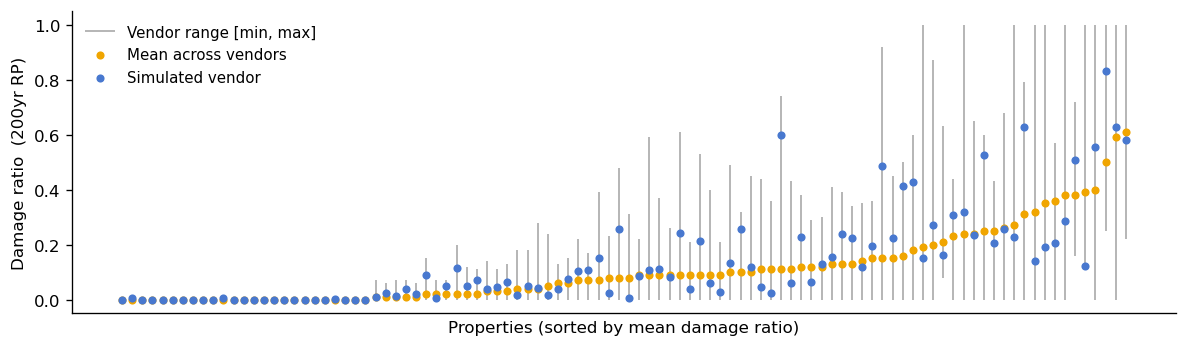

In [5]:
# Vendor spread by property
mean_d   = results['d_mean'].values[idx]
min_d    = results['d_min'].values[idx]
max_d    = results['d_max'].values[idx]
vendor_d = results['d_vendor'].values[idx]

fig, ax = plt.subplots(figsize=(10, 3))
ax.vlines(x_pos, min_d, max_d, color=GREY, linewidth=1.2, alpha=0.6,
          label='Vendor range [min, max]')
ax.scatter(x_pos, mean_d,   color=AMBER, s=15, zorder=3, label='Mean across vendors')
ax.scatter(x_pos, vendor_d, color=BLUE,  s=15, zorder=3, label='Simulated vendor')
ax.set_xlabel('Properties (sorted by mean damage ratio)')
ax.set_ylabel('Damage ratio  (200yr RP)')
ax.set_xticks([])
ax.legend(frameon=False, fontsize=9, loc='upper left')
plt.tight_layout()
plt.show()

---
## TAU Comparison: Side-by-side figures across two SICR thresholds

Edit `TAU_A`, `TAU_B`, and `FRAMING_COMPARE` in the next cell, then run all cells in this section.

In [11]:
# =============================================================================
# TAU COMPARISON -- parameters
# Edit these three variables; everything below recomputes automatically.
# =============================================================================

TAU_A           = 2.0    # SICR threshold A  (EBA benchmark)
TAU_B           = 1.5    # SICR threshold B  (stricter / more conservative)
FRAMING_COMPARE = 'aal'  # 'conditional'  or  'aal'
N_DRAWS_COMPARE = 1000   # vendor draws for uncertainty analysis

In [13]:
# =============================================================================
# TAU COMPARISON -- computation
# Runs the full reduced-form simulation for each of TAU_A and TAU_B.
# Depends on: data / portfolio variables from cells 2+; ALPHA, LAMBDA_LGD,
#             PD_FUNCTIONAL_FORM, AAL_FACTOR, VENDOR_SEED from cell 1.
# =============================================================================

def _run_tau_sim(tau, framing, n_draws):
    """Return all arrays needed for the five side-by-side comparison figures."""
    # single vendor draw (SICR / ECL bar charts)
    d_v  = triangular_sample(np.random.default_rng(VENDOR_SEED), tri_a, tri_b, tri_c)
    d1   = d_v if framing == 'conditional' else d_v * AAL_FACTOR
    mult1  = np.exp(ALPHA * d1) if PD_FUNCTIONAL_FORM == 'exponential' else (1.0 + ALPHA * d1)
    pd12_1 = np.clip(pd_12m_base * mult1, 0, 0.9999)
    lgd_1  = np.minimum(lgd_base + LAMBDA_LGD * d1, 1.0)
    pdlt_1 = 1.0 - (1.0 - pd12_1) ** maturity
    sicr_1 = pdlt_1 / np.maximum(pd_lt_base, 1e-12)
    stage_1 = np.where(sicr_1 > tau, 2, 1)
    ecl_1   = compute_ecl(pd12_1, pdlt_1, lgd_1, ead_m, stage_1)

    # N vendor draws (uncertainty sweep + pairwise)
    _rng  = np.random.default_rng(0)
    d_mat = np.stack([triangular_sample(_rng, tri_a, tri_b, tri_c) for _ in range(n_draws)])
    d_eff = d_mat if framing == 'conditional' else d_mat * AAL_FACTOR
    mult_m  = np.exp(ALPHA * d_eff) if PD_FUNCTIONAL_FORM == 'exponential' else (1.0 + ALPHA * d_eff)
    pd12_m  = np.clip(pd_12m_base[None, :] * mult_m, 0, 0.9999)
    lgd_m   = np.minimum(lgd_base[None, :] + LAMBDA_LGD * d_eff, 1.0)
    pdlt_m  = 1.0 - (1.0 - pd12_m) ** maturity[None, :]
    sicr_m  = pdlt_m / np.maximum(pd_lt_base[None, :], 1e-12)
    stage_m = (sicr_m > tau).astype(int) + 1
    ecl_m   = np.where(stage_m == 2,
                       pdlt_m * lgd_m * ead_m[None, :],
                       pd12_m * lgd_m * ead_m[None, :])
    port_ecl = ecl_m.sum(axis=1)
    s_max     = stage_m.max(axis=0)
    s_min     = stage_m.min(axis=0)
    always_s1 = s_max == 1
    always_s2 = s_min == 2
    unstable  = ~always_s1 & ~always_s2

    # pairwise ECL disagreement
    ii, jj   = np.triu_indices(n_draws, k=1)
    ecl_diff = np.abs(port_ecl[ii] - port_ecl[jj])

    return dict(
        tau=tau, framing=framing,
        sicr_single=sicr_1, stage_single=stage_1, ecl_single=ecl_1,
        port_ecl=port_ecl, ecl_draws=ecl_m,
        always_s1=always_s1, always_s2=always_s2, unstable=unstable,
        ecl_diff=ecl_diff,
    )


_fl = ('Conditional  (p=1)' if FRAMING_COMPARE == 'conditional'
       else f'AAL  (d×{AAL_FACTOR})')

sim_a = _run_tau_sim(TAU_A, FRAMING_COMPARE, N_DRAWS_COMPARE)
sim_b = _run_tau_sim(TAU_B, FRAMING_COMPARE, N_DRAWS_COMPARE)

for s in (sim_a, sim_b):
    n2 = (s['stage_single'] == 2).sum()
    print(f"tau={s['tau']:.1f}  |  Stage 2 (single draw): {n2:2d} loans  "
          f"|  Mean portfolio ECL: GBP{s['port_ecl'].mean():.4f}m  "
          f"|  {_fl}")

tau=2.0  |  Stage 2 (single draw):  0 loans  |  Mean portfolio ECL: GBP0.6429m  |  AAL  (d×0.25)
tau=1.5  |  Stage 2 (single draw):  4 loans  |  Mean portfolio ECL: GBP0.8966m  |  AAL  (d×0.25)


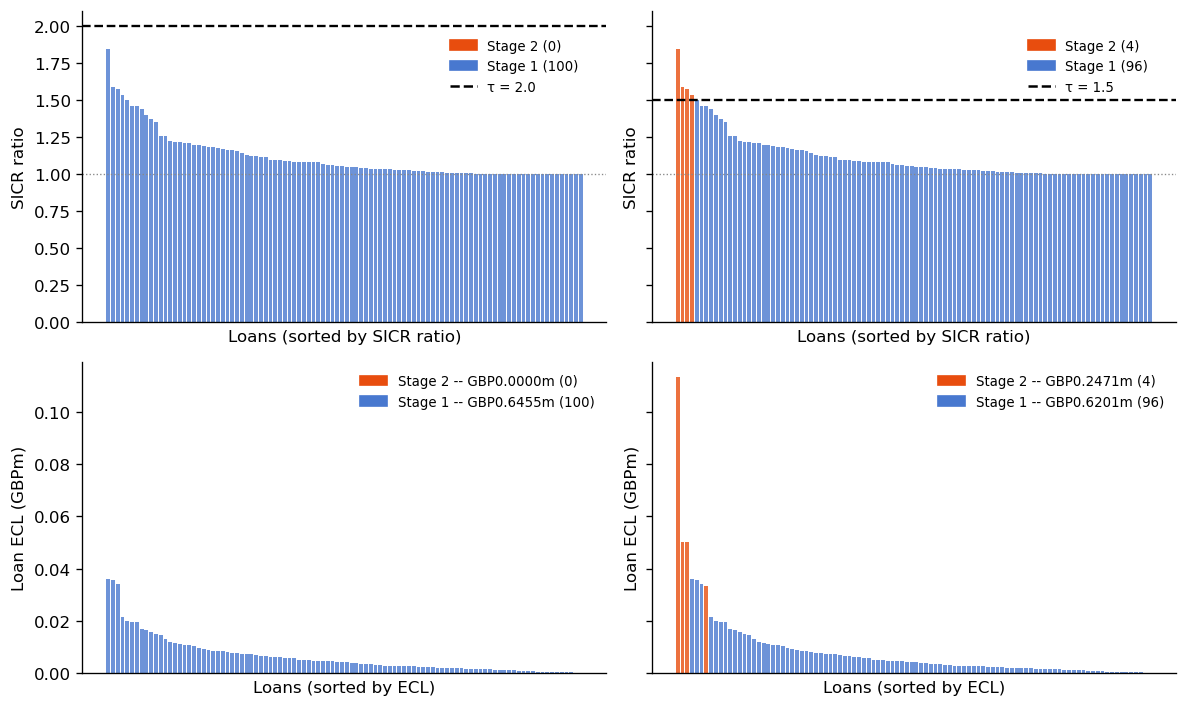

In [15]:
# Figure 1 -- 2x2: SICR ratios (top row) and Loan ECL (bottom row), tau_A vs tau_B
# Top row shares Y axis; bottom row shares Y axis.
fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharey='row')

# ── top row: SICR ratios ─────────────────────────────────────────────────
for ax, s in zip(axes[0], (sim_a, sim_b)):
    tau     = s['tau']
    sicr    = s['sicr_single']
    stage   = s['stage_single']
    order   = np.argsort(sicr)[::-1]
    n_s2    = (stage == 2).sum()
    colours = [RED if stage[o] == 2 else BLUE for o in order]
    ax.bar(np.arange(n), sicr[order], color=colours, width=0.8, alpha=0.8)
    ax.axhline(tau, color='black', linewidth=1.4, linestyle='--')
    ax.axhline(1.0, color=GREY,   linewidth=0.8, linestyle=':')
    ax.set_xlabel('Loans (sorted by SICR ratio)')
    ax.set_ylabel('SICR ratio')
    # ax.set_title(f'τ = {tau}  |  Stage 2: {n_s2} loans')
    ax.set_xticks([])
    ax.legend(handles=[
        mpatches.Patch(color=RED,  label=f'Stage 2 ({n_s2})'),
        mpatches.Patch(color=BLUE, label=f'Stage 1 ({n - n_s2})'),
        plt.Line2D([0],[0], color='black', linestyle='--', label=f'τ = {tau}'),
    ],
    loc='upper right', bbox_to_anchor=(0.97, 0.95), frameon=False, fontsize=8)

# ── bottom row: Loan ECL ─────────────────────────────────────────────────
for ax, s in zip(axes[1], (sim_a, sim_b)):
    tau     = s['tau']
    ecl     = s['ecl_single']
    stage   = s['stage_single']
    order   = np.argsort(ecl)[::-1]
    n_s2    = (stage == 2).sum()
    ecl_s1  = ecl[stage == 1].sum()
    ecl_s2  = ecl[stage == 2].sum()
    colours = [RED if stage[o] == 2 else BLUE for o in order]
    ax.bar(np.arange(n), ecl[order], color=colours, width=0.8, alpha=0.8)
    ax.set_xlabel('Loans (sorted by ECL)')
    ax.set_ylabel('Loan ECL (GBPm)')
    # ax.set_title(f'τ = {tau}  |  Total GBP{ecl.sum():.4f}m  ({ecl.sum()/ead_m.sum()*1e4:.1f} bps)')
    ax.set_xticks([])
    ax.legend(handles=[
        mpatches.Patch(color=RED,  label=f'Stage 2 -- GBP{ecl_s2:.4f}m ({n_s2})'),
        mpatches.Patch(color=BLUE, label=f'Stage 1 -- GBP{ecl_s1:.4f}m ({n - n_s2})'),
    ], frameon=False, fontsize=8)

# fig.suptitle(f'SICR Ratios (top) and Loan ECL (bottom)  |  τ={TAU_A} vs τ={TAU_B}  |  {_fl}',
#              fontsize=10, y=1.01)
plt.tight_layout()
plt.show()

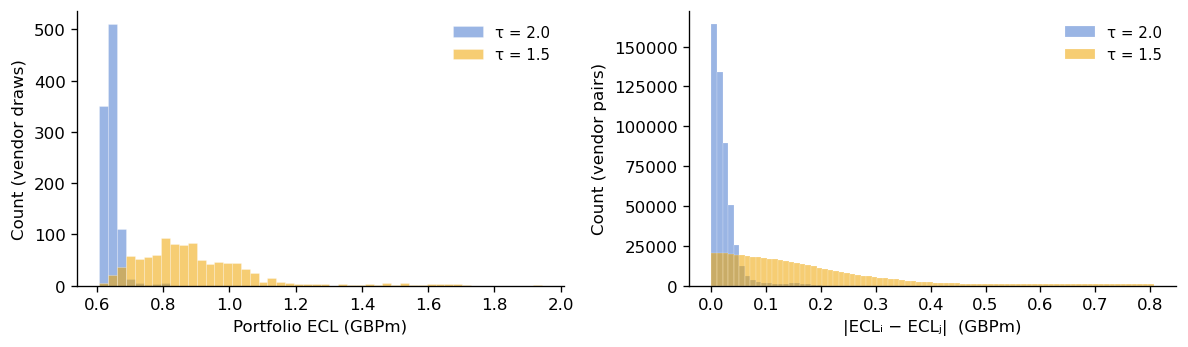

In [62]:
# Figure 2 -- overlaid histograms: Portfolio ECL (left) and ECL disagreement (right)
# Both tau scenarios shown on the same axes with different colours.
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# ── left: Portfolio ECL distribution ────────────────────────────────────
ax = axes[0]
all_port = np.concatenate([sim_a['port_ecl'], sim_b['port_ecl']])
bins_port = np.linspace(all_port.min(), all_port.max(), 51)
for s, col in ((sim_a, BLUE), (sim_b, AMBER)):
    tau = s['tau']
    ax.hist(s['port_ecl'], bins=bins_port, color=col, alpha=0.55,
            edgecolor='white', linewidth=0.3, label=f'τ = {tau}')
    # ax.axvline(s['port_ecl'].mean(), color=col, linewidth=1.4, linestyle='--')
# ax.axvline(results['ecl_base'].sum(), color=GREY, linewidth=1.2, linestyle=':',
#            label='Baseline')
ax.set_xlabel('Portfolio ECL (GBPm)')
ax.set_ylabel('Count (vendor draws)')
# ax.set_title(f'Portfolio ECL distribution')
ax.legend(frameon=False, fontsize=9)

# ── right: ECL disagreement between vendor pairs ─────────────────────────
ax = axes[1]
all_diff = np.concatenate([sim_a['ecl_diff'], sim_b['ecl_diff']])
bins_diff = np.linspace(0, np.percentile(all_diff, 99), 81)
for s, col in ((sim_a, BLUE), (sim_b, AMBER)):
    tau = s['tau']
    med = np.median(s['ecl_diff'])
    ax.hist(s['ecl_diff'], bins=bins_diff, color=col, alpha=0.55,
            edgecolor='white', linewidth=0.2, label=f'τ = {tau}')
    # ax.axvline(med, color=col, linewidth=1.4, linestyle='--')
ax.set_xlabel('|ECLᵢ − ECLⱼ|  (GBPm)')
ax.set_ylabel('Count (vendor pairs)')
# ax.set_title(f'ECL disagreement between vendor pairs  |  {_fl}\n'
#              f'Dashed lines = medians')
ax.legend(frameon=False, fontsize=9)

# fig.suptitle(f'τ={TAU_A} vs τ={TAU_B}  |  {_fl}', fontsize=10, y=1.01)
plt.tight_layout()
plt.show()

In [63]:
# =============================================================================
# SUMMARY STATISTICS FOR REPORT
# Reports all key metrics for both tau scenarios side-by-side.
# Depends on: sim_a, sim_b, ead_m, results, N_DRAWS_COMPARE, TAU_A, TAU_B, _fl
# =============================================================================

ead_total      = ead_m.sum()
ecl_base_total = results['ecl_base'].sum()

def _stats_for(s):
    port     = s['port_ecl']
    diff     = s['ecl_diff']
    stage    = s['stage_single']
    ecl      = s['ecl_single']
    unstable = s['unstable']
    a_s1     = s['always_s1']
    a_s2     = s['always_s2']
    ecl_s2   = ecl[stage == 2].sum()
    ecl_s1   = ecl[stage == 1].sum()
    return {
        # ── single vendor draw ──────────────────────────────────────────────
        'Stage 2 loans':                         int((stage == 2).sum()),
        'Stage 1 loans':                         int((stage == 1).sum()),
        'ECL Stage 2 (GBPm)':                    round(ecl_s2, 4),
        'ECL Stage 1 (GBPm)':                    round(ecl_s1, 4),
        'Portfolio ECL — single draw (GBPm)':    round(ecl.sum(), 4),
        'Portfolio ECL — single draw (bps EAD)': round(ecl.sum() / ead_total * 1e4, 2),
        # ── vendor uncertainty (N draws) ────────────────────────────────────
        'ECL mean across vendors (GBPm)':        round(port.mean(), 4),
        'ECL mean across vendors (bps EAD)':     round(port.mean() / ead_total * 1e4, 2),
        'ECL std across vendors (GBPm)':         round(port.std(), 4),
        'ECL CV across vendors':                 round(port.std() / port.mean(), 4),
        'ECL P10 (GBPm)':                        round(float(np.percentile(port, 10)), 4),
        'ECL P25 (GBPm)':                        round(float(np.percentile(port, 25)), 4),
        'ECL P50 / median (GBPm)':               round(float(np.percentile(port, 50)), 4),
        'ECL P75 (GBPm)':                        round(float(np.percentile(port, 75)), 4),
        'ECL P90 (GBPm)':                        round(float(np.percentile(port, 90)), 4),
        'ECL range P90/P10 ratio':               round(float(np.percentile(port, 90) / np.percentile(port, 10)), 3),
        'ECL range / mean':                      round((port.max() - port.min()) / port.mean(), 3),
        # ── staging stability ───────────────────────────────────────────────
        'Always Stage 1 (n loans)':              int(a_s1.sum()),
        'Unstable — flip stage (n loans)':       int(unstable.sum()),
        'Always Stage 2 (n loans)':              int(a_s2.sum()),
        'Staging instability rate':              round(float(unstable.mean()), 4),
        # ── pairwise vendor comparison ──────────────────────────────────────
        'Pairwise |\u0394ECL| median (GBPm)':       round(float(np.median(diff)), 4),
        'Pairwise |\u0394ECL| P90 (GBPm)':          round(float(np.percentile(diff, 90)), 4),
        'Pairwise |\u0394ECL| median (% mean ECL)':  round(float(np.median(diff)) / port.mean() * 100, 2),
    }

col_a = f'\u03c4 = {TAU_A}'
col_b = f'\u03c4 = {TAU_B}'
df_stats = pd.DataFrame({col_a: _stats_for(sim_a), col_b: _stats_for(sim_b)})
df_stats['Diff (B \u2212 A)'] = pd.to_numeric(df_stats[col_b], errors='coerce') - pd.to_numeric(df_stats[col_a], errors='coerce')

# Section dividers (blank rows) — use NaN rows as visual separators
sep = pd.Series({'__section__': True}, name=' ')
sections = [
    ('Single vendor draw', [
        'Stage 2 loans', 'Stage 1 loans',
        'ECL Stage 2 (GBPm)', 'ECL Stage 1 (GBPm)',
        'Portfolio ECL — single draw (GBPm)', 'Portfolio ECL — single draw (bps EAD)',
    ]),
    ('Vendor uncertainty (N draws)', [
        'ECL mean across vendors (GBPm)', 'ECL mean across vendors (bps EAD)',
        'ECL std across vendors (GBPm)', 'ECL CV across vendors',
        'ECL P10 (GBPm)', 'ECL P25 (GBPm)', 'ECL P50 / median (GBPm)',
        'ECL P75 (GBPm)', 'ECL P90 (GBPm)',
        'ECL range P90/P10 ratio', 'ECL range / mean',
    ]),
    ('Staging stability', [
        'Always Stage 1 (n loans)', 'Unstable \u2014 flip stage (n loans)',
        'Always Stage 2 (n loans)', 'Staging instability rate',
    ]),
    ('Pairwise vendor comparison', [
        'Pairwise |\u0394ECL| median (GBPm)',
        'Pairwise |\u0394ECL| P90 (GBPm)',
        'Pairwise |\u0394ECL| median (% mean ECL)',
    ]),
]

print(f'Framing: {_fl}  |  N vendor draws = {N_DRAWS_COMPARE}')
print(f'Reference baseline ECL: GBP{ecl_base_total:.4f}m  ({ecl_base_total/ead_total*1e4:.2f} bps of EAD)')
print(f'Total EAD: GBP{ead_total:.2f}m\n')

for section_name, keys in sections:
    print(f'\n--- {section_name} ---')
    display(df_stats.loc[keys].style
            .format(lambda v: f'{v:.4g}' if isinstance(v, float) else (str(v) if pd.notna(v) else ''),
                    subset=[col_a, col_b])
            .format(lambda v: f'{v:+.4g}' if pd.notna(v) else '', subset=['Diff (B \u2212 A)'])
            .set_caption(section_name)
            .set_table_styles([{'selector': 'caption',
                                'props': [('font-weight', 'bold'), ('font-size', '1em')]}]))

Framing: AAL  (d×0.25)  |  N vendor draws = 1000
Reference baseline ECL: GBP0.5390m  (20.03 bps of EAD)
Total EAD: GBP269.02m


--- Single vendor draw ---


,τ = 2.0,τ = 1.5,Diff (B − A)
Stage 2 loans,0,4,+4
Stage 1 loans,100,96,-4
ECL Stage 2 (GBPm),0,0.2471,+0.2471
ECL Stage 1 (GBPm),0.6455,0.6201,-0.0254
Portfolio ECL — single draw (GBPm),0.6455,0.8672,+0.2217
Portfolio ECL — single draw (bps EAD),24,32.24,+8.24



--- Vendor uncertainty (N draws) ---


,τ = 2.0,τ = 1.5,Diff (B − A)
ECL mean across vendors (GBPm),0.6429,0.8966,+0.2537
ECL mean across vendors (bps EAD),23.9,33.33,+9.43
ECL std across vendors (GBPm),0.0236,0.1892,+0.1656
ECL CV across vendors,0.0366,0.211,+0.1744
ECL P10 (GBPm),0.6212,0.7066,+0.0854
ECL P25 (GBPm),0.6283,0.7795,+0.1512
ECL P50 / median (GBPm),0.639,0.8592,+0.2202
ECL P75 (GBPm),0.6512,0.9758,+0.3246
ECL P90 (GBPm),0.6655,1.074,+0.4087
ECL range P90/P10 ratio,1.071,1.52,+0.449



--- Staging stability ---


,τ = 2.0,τ = 1.5,Diff (B − A)
Always Stage 1 (n loans),93,77,-16
Unstable — flip stage (n loans),7,23,+16
Always Stage 2 (n loans),0,0,+0
Staging instability rate,0.07,0.23,+0.16



--- Pairwise vendor comparison ---


,τ = 2.0,τ = 1.5,Diff (B − A)
Pairwise |ΔECL| median (GBPm),0.0161,0.1366,+0.1205
Pairwise |ΔECL| P90 (GBPm),0.0442,0.4111,+0.3669
Pairwise |ΔECL| median (% mean ECL),2.51,15.24,+12.73
